In [1]:
import yaramod
import yara
import re
import pandas as pd

In [12]:
file_path='/home/mabon/research/Autoyara/YaraResults/ruleEval/originalBloomFilters/sdhash/AutoYaraBaseline/Th50rules/merged_group_1.yar'
ymod = yaramod.Yaramod()
yara_file_parsed = ymod.parse_file(file_path)
rules = yara_file_parsed.rules
df = pd.DataFrame(columns=['clusterNumber', 'runNumber','hexLength','mainConditionOR','ConditionAnd'])

for rule in rules:
    match = re.match(r'Cluster(\d+)_(\d+)', rule.name.strip())
    cluster_number = int(match.group(1))
    run_number = int(match.group(2))
    numberConditions=0
    strLength=0
    for string in rule.strings:
        numberConditions+=1
        string_text =string.text
        hex_values = re.findall(r'\b[0-9A-Fa-f]{2}\b', string_text)
        # Count the number of hex bytes
        strLength += len(hex_values)
    
    condition_text = rule.condition.text  # Replace with actual condition string if testing directly
    # Match expressions like: 3 of ($x0, $x1, ...)
    matches = re.findall(r'\d+\s+of\s+\([^)]+\)', condition_text)
    NumberMainConditions = len(matches)
    df.loc[len(df)] = [cluster_number, run_number, strLength, NumberMainConditions, numberConditions]

# Average a specific column
avg_hex = df['hexLength'].mean()
avg_or = df['mainConditionOR'].mean()
avg_and = df['ConditionAnd'].mean()

print(f"Average hexLength: {avg_hex}")
print(f"Average mainConditionOR: {avg_or}")
print(f"Average ConditionAnd: {avg_and}")


median_hex = df['hexLength'].median()
median_or = df['mainConditionOR'].median()
median_and = df['ConditionAnd'].median()

print(f"Median hexLength: {median_hex}")
print(f"Median mainConditionOR: {median_or}")
print(f"Median ConditionAnd: {median_and}")


Average hexLength: 611.5287720888083
Average mainConditionOR: 1.1306449176861502
Average ConditionAnd: 4.0299803655037
Median hexLength: 8.0
Median mainConditionOR: 1.0
Median ConditionAnd: 1.0


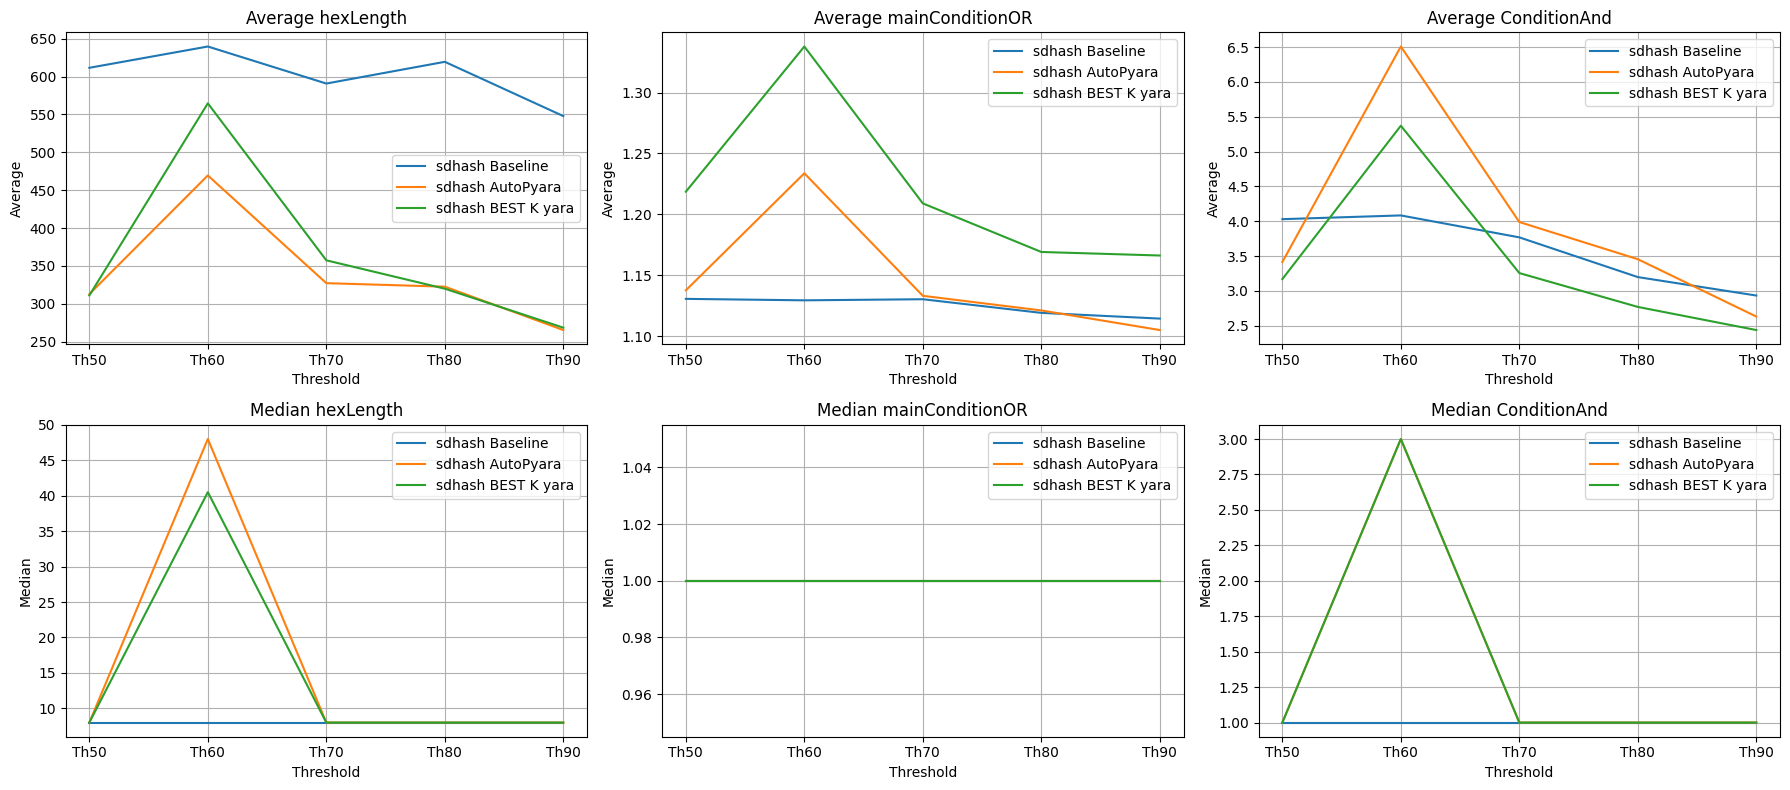

In [17]:
import matplotlib.pyplot as plt
import pandas as pd

# Define the data
thresholds = ['Th50', 'Th60', 'Th70', 'Th80', 'Th90']
# Updated values for SDHash systems
data = {
    'sdhash Baseline': {
        'avg_hex': [611.53, 639.64, 590.74, 619.43, 547.78],
        'avg_or':  [1.1306, 1.1294, 1.1303, 1.1191, 1.1144],
        'avg_and': [4.0300, 4.0837, 3.7688, 3.1989, 2.9342],
        'med_hex': [8, 8, 8, 8, 8],
        'med_or':  [1, 1, 1, 1, 1],
        'med_and': [1, 1, 1, 1, 1],
    },
    'sdhash AutoPyara': {
        'avg_hex': [312.72, 469.41, 327.17, 322.53, 265.27],
        'avg_or':  [1.1376, 1.2337, 1.1331, 1.1211, 1.1050],
        'avg_and': [3.4148, 6.5074, 3.9887, 3.4557, 2.6326],
        'med_hex': [8, 48, 8, 8, 8],
        'med_or':  [1, 1, 1, 1, 1],
        'med_and': [1, 3, 1, 1, 1],
    },
    'sdhash BEST K yara': {
        'avg_hex': [310.99, 564.63, 357.33, 319.87, 268.42],
        'avg_or':  [1.2186, 1.3378, 1.2090, 1.1691, 1.1662],
        'avg_and': [3.1704, 5.3707, 3.2565, 2.7708, 2.4390],
        'med_hex': [8, 40.5, 8, 8, 8],
        'med_or':  [1, 1, 1, 1, 1],
        'med_and': [1, 3, 1, 1, 1],
    }
}

# Create plots
metrics = ['hex', 'or', 'and']
titles = {
    'hex': 'hexLength',
    'or': 'mainConditionOR',
    'and': 'ConditionAnd'
}

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    for name, values in data.items():
        axes[i].plot(thresholds, values[f'avg_{metric}'], label=name)
    axes[i].set_title(f'Average {titles[metric]}')
    axes[i].set_xlabel('Threshold')
    axes[i].set_ylabel('Average')
    axes[i].legend()
    axes[i].grid(True)

for i, metric in enumerate(metrics):
    for name, values in data.items():
        axes[i+3].plot(thresholds, values[f'med_{metric}'], label=name)
    axes[i+3].set_title(f'Median {titles[metric]}')
    axes[i+3].set_xlabel('Threshold')
    axes[i+3].set_ylabel('Median')
    axes[i+3].legend()
    axes[i+3].grid(True)

plt.tight_layout()
plt.show()
